In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from dotenv import load_dotenv
import os
from ConfigSpace.read_and_write import pcs_new
import wandb
load_dotenv()

/tmp/ipykernel_89608/2024532949.py:6: DeprecationWarning: Modules pcs and pcs_new are deprecated but will remain without future support. 
  from ConfigSpace.read_and_write import pcs_new


True

In [3]:
casmo_table = pd.read_csv("distance_data/wandb_export_2026-03-18T15_38_29.970+01_00.csv")
# casmo_configspace =

In [4]:
# with wandb.init(project="Styx", job_type="read-table") as run:
#     artifact = run.use_artifact("/Styx/run-7a1mmyef-all_X:latest", type="run_table")
#     table = artifact.get("all_X")
#     # Now you can use the table, for example converting to a pandas dataframe
#     casmo_table = table.get_dataframe()
    # print(df.head())

In [5]:
artifact = wandb.Api().artifact("/Styx/run-7a1mmyef-all_X:latest", type="run_table")
table = artifact.get("all_X")
# Now you can use the table, for example converting to a pandas dataframe
casmo_table = table.get_dataframe()
display(casmo_table.head())

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/skippybal/.netrc.
wandb:   1 of 1 files downloaded.  


,run_id,aggregate,auto_aggfill_on,auto_barcorrectors,auto_barhomogeneous,auto_barorder,auto_bqpcuts_on,auto_branchdir_on,auto_cliquecuts_on,auto_covercuts_on,...,relaxliftcuts,rins,rltcuts,sifting,startnodelimit,strongcgcuts,submipcuts,symmetry,zerohalfcuts,zeroobjnodes
0,1,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,2.0,40.0,2.0,1.0,245439.0,1.0,1.0,0.0,1.0,1191754.0
1,2,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,44.0,1.0,2.0,728952.0,0.0,1.0,2.0,0.0,856238.0
2,3,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,...,1.0,53.0,0.0,2.0,1980658.0,2.0,0.0,0.0,1.0,1569736.0
3,4,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,...,1.0,39.0,1.0,1.0,333658.0,1.0,2.0,2.0,1.0,1210712.0
4,5,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,29.0,1.0,1.0,1862366.0,1.0,2.0,2.0,1.0,476932.0


In [6]:
param_file_loc = os.getenv('PARAM_FILE_LOC')
    # load_dotenv()
    # breakpoint()
with open(param_file_loc, 'r') as fh:
    casmo_configspace = pcs_new.read(fh)
casmo_configspace.seed(721)
print(casmo_configspace)

Configuration space object:
  Hyperparameters:
    aggfill, Type: UniformInteger, Range: [1, 2048], Default: 1024
    aggregate, Type: Categorical, Choices: {0, 1}, Default: 1
    auto_aggfill_on, Type: Categorical, Choices: {0, 1}, Default: 1
    auto_barcorrectors, Type: Categorical, Choices: {0, 1}, Default: 1
    auto_barhomogeneous, Type: Categorical, Choices: {0, 1}, Default: 1
    auto_barorder, Type: Categorical, Choices: {0, 1}, Default: 1
    auto_bqpcuts_on, Type: Categorical, Choices: {0, 1}, Default: 1
    auto_branchdir_on, Type: Categorical, Choices: {0, 1}, Default: 1
    auto_cliquecuts_on, Type: Categorical, Choices: {0, 1}, Default: 1
    auto_covercuts_on, Type: Categorical, Choices: {0, 1}, Default: 1
    auto_crossover, Type: Categorical, Choices: {0, 1}, Default: 1
    auto_cutaggpasses_on, Type: Categorical, Choices: {0, 1}, Default: 1
    auto_cutpasses_on, Type: Categorical, Choices: {0, 1}, Default: 1
    auto_cuts_on, Type: Categorical, Choices: {0, 1}, Defa

/tmp/ipykernel_89608/4008333141.py:5: DeprecationWarning: pcs_new.read is has stopped being maintained, please use `space.to_json` or `space.to_yaml` instead
  casmo_configspace = pcs_new.read(fh)


In [7]:
import ConfigSpace.hyperparameters.categorical
cont_names = set()
cat_names = set()

int_names = []
#TODO: make a default section here? can just get from configspace as well i think

# print(dict(deserialized_conf))
for index, (name, obj) in enumerate(dict(casmo_configspace).items()):

    if type(obj) == ConfigSpace.hyperparameters.categorical.CategoricalHyperparameter:

        cat_names.add(name)

    elif type(obj) == ConfigSpace.hyperparameters.uniform_integer.UniformIntegerHyperparameter:
        cont_names.add(name)

    elif type(obj) == ConfigSpace.hyperparameters.uniform_float.UniformFloatHyperparameter:
        cont_names.add(name)

    else:
        print(f"unknown: {obj}")

print(cont_names)
print(cat_names)


{'mipsepcuts', 'presolve', 'improvestartgap', 'cutaggpasses', 'heuristics', 'flowpathcuts', 'impliedcuts', 'zeroobjnodes', 'relaxliftcuts', 'degenmoves', 'networkcuts', 'barcorrectors', 'covercuts', 'minrelnodes', 'submipnodes', 'bqpcuts', 'disconnected', 'zerohalfcuts', 'rltcuts', 'gubcovercuts', 'gomorypasses', 'rins', 'perturbvalue', 'cutpasses', 'pumppasses', 'startnodelimit', 'infproofcuts', 'projimpliedcuts', 'improvestarttime', 'prepasses', 'symmetry', 'cliquecuts', 'modkcuts', 'aggfill', 'strongcgcuts', 'submipcuts', 'mircuts', 'sifting', 'cuts', 'flowcovercuts', 'improvestartnodes'}
{'auto_zeroobjnodes_on', 'partitionplace', 'branchdir', 'auto_degenmoves_on', 'barhomogeneous', 'auto_normadjust_on', 'auto_modkcuts_on', 'auto_predual_on', 'auto_cutpasses_on', 'auto_disconnected_on', 'auto_projimpliedcuts_on', 'quad', 'varbranch', 'auto_barhomogeneous', 'auto_mipsepcuts_on', 'auto_submipcuts_on', 'auto_relaxliftcuts_on', 'issmethod', 'siftmethod', 'auto_symmetry_on', 'nodemethod'

In [8]:
# TODO: how are we going to deal with the continuous ones that are dependen on the other? dist to defualt?

### Hamming

In [9]:
def build_hamming_dist_mat(configspace, config_table, cat_names, cont_names):
    print(len(config_table))
    dists = np.zeros((len(config_table), len(config_table)))
    print(dists.shape)
    for i in range(dists.shape[0]):
        for j in range(i, dists.shape[1]):
            # print(config_table.iloc[i])
            # print(config_table.iloc[i]["auto_issmethod_on"])
            # print(config_table.iloc[i]["auto_barhomogeneous"])
            # print(config_table.iloc[j]["auto_barhomogeneous"])

            for cat_var in cat_names:
                if config_table.iloc[i][cat_var] != config_table.iloc[j][cat_var]:
                    # print("different")
                    # print(config_table.iloc[i][cat_var])
                    # print(config_table.iloc[j][cat_var])
                    dists[i,j] += 1
    return dists


casmo_hat_dist = build_hamming_dist_mat(casmo_configspace, casmo_table, cat_names, cont_names)
print(casmo_hat_dist)

45
(45, 45)
[[ 0. 37. 44. ... 40. 39. 40.]
 [ 0.  0. 39. ... 32. 34. 34.]
 [ 0.  0.  0. ... 42. 43. 43.]
 ...
 [ 0.  0.  0. ...  0.  5.  3.]
 [ 0.  0.  0. ...  0.  0.  4.]
 [ 0.  0.  0. ...  0.  0.  0.]]


<Axes: >

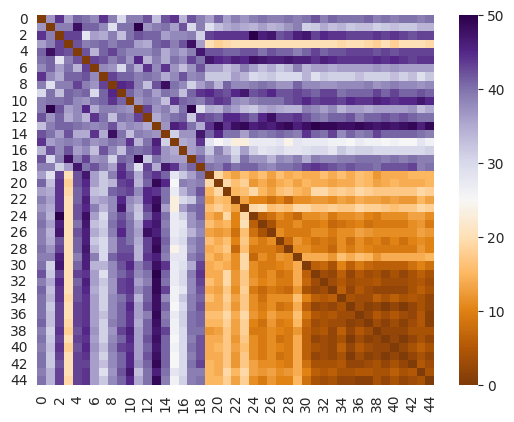

In [10]:
sns.heatmap(casmo_hat_dist + casmo_hat_dist.T, cmap="PuOr")

In [11]:
# casmo_hat_dist = build_manhatten_dist_mat(casmo_configspace, casmo_table, cat_names, cont_names)

### Euc

In [12]:
def build_euc_dist_mat(configspace, config_table, cat_names, cont_names):
    print(len(config_table))
    dists = np.zeros((len(config_table), len(config_table)))
    print(dists.shape)
    for i in range(dists.shape[0]):
        for j in range(i, dists.shape[1]):
            # print(config_table.iloc[i])
            # print(config_table.iloc[i]["auto_issmethod_on"])
            # print(config_table.iloc[i]["auto_barhomogeneous"])
            # print(config_table.iloc[j]["auto_barhomogeneous"])

            for con_var in cont_names:
                # if config_table.iloc[i][con_var] != config_table.iloc[j][con_var]:
                #     # print("different")
                try:
                    # print(con_var)
                    # print(config_table.iloc[i][con_var])
                    # print(config_table.iloc[j][con_var])
                    dists[i,j] += (config_table.iloc[i][con_var] - config_table.iloc[j][con_var]) ** 2
                except Exception as e:
                    print(e)
                    print(f"Variable not found?: {con_var}")


                # dists[i,j] += (config_table.iloc[i][con_var] - config_table.iloc[j][con_var]) ** 2
    return np.sqrt(dists)

In [68]:
def build_euc_dist_mat_normalized(configspace, config_table, cat_names, cont_names):

    def min_max_normalized(value, min_val, max_val):
        return (value - min_val)/(max_val-min_val)

    print(len(config_table))
    dists = np.zeros((len(config_table), len(config_table)))
    print(dists.shape)
    for i in range(dists.shape[0]):
        for j in range(i, dists.shape[1]):

            for con_var in cont_names:
                # print(configspace[con_var])
                # print(configspace[con_var].lower)
                # print(configspace[con_var].upper)
                # print(configspace[con_var].range)
                try:

                    var_min = configspace[con_var].lower
                    var_max = configspace[con_var].upper

                    dists[i,j] += (min_max_normalized(config_table.iloc[i][con_var], var_min, var_max) - min_max_normalized(config_table.iloc[j][con_var], var_min, var_max)) ** 2
                except Exception as e:
                    print(e)
                    print(f"Variable not found?: {con_var}")


                # dists[i,j] += (config_table.iloc[i][con_var] - config_table.iloc[j][con_var]) ** 2
    return np.sqrt(dists)
casmo_euc_dist_normalized = build_euc_dist_mat_normalized(casmo_configspace, casmo_table, cat_names, cont_names)

45
(45, 45)


In [13]:
print(casmo_table.columns)
print(len(casmo_table.columns))
print(len(cat_names))
print(len(cont_names))

Index(['run_id', 'aggregate', 'auto_aggfill_on', 'auto_barcorrectors',
       'auto_barhomogeneous', 'auto_barorder', 'auto_bqpcuts_on',
       'auto_branchdir_on', 'auto_cliquecuts_on', 'auto_covercuts_on',
       ...
       'relaxliftcuts', 'rins', 'rltcuts', 'sifting', 'startnodelimit',
       'strongcgcuts', 'submipcuts', 'symmetry', 'zerohalfcuts',
       'zeroobjnodes'],
      dtype='object', length=112)
112
70
41


The table is 11 variables shorter then it should be.... and it's exatctely the ones we seem to be missing

In [14]:
casmo_euc_dist = build_euc_dist_mat(casmo_configspace, casmo_table, cat_names, cont_names)
print(casmo_euc_dist)

45
(45, 45)
[[      0.         2301597.99657463 2397939.59529362 ... 1688707.05190443
  2316083.86184002 1136660.3516951 ]
 [      0.               0.         2611067.64677163 ... 2061765.7770203
  1635905.81522794 2197643.04622323]
 [      0.               0.               0.         ... 1846043.32616649
  1945180.23929376 2696518.4005093 ]
 ...
 [      0.               0.               0.         ...       0.
  1654396.923567   1274345.10570995]
 [      0.               0.               0.         ...       0.
        0.         2358215.8960321 ]
 [      0.               0.               0.         ...       0.
        0.               0.        ]]


<Axes: >

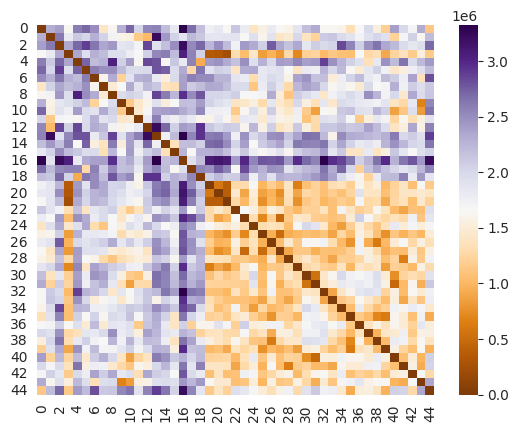

In [15]:
sns.heatmap(casmo_euc_dist + casmo_euc_dist.T, cmap="PuOr")

The scale is 1e6, so we really should normalize the distances per variable here becase this plot is likely highly dominated by a single variable with a very large range #TODO

### Normalized Euc

<Axes: >

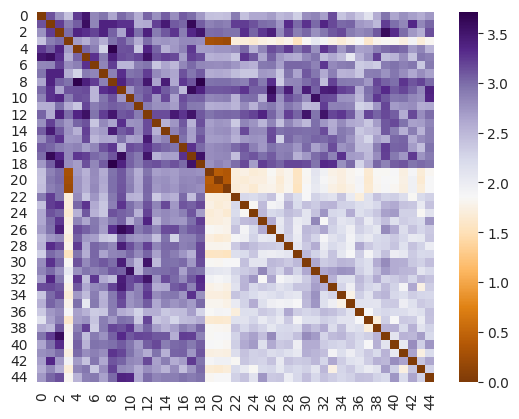

In [70]:
sns.heatmap(casmo_euc_dist_normalized + casmo_euc_dist_normalized.T, cmap="PuOr")

### Full unnormalized

<Axes: >

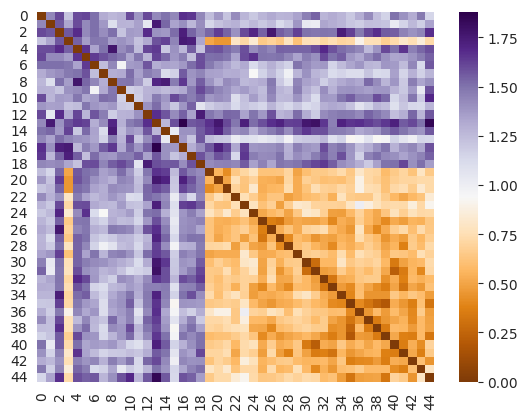

In [16]:
full_euc = casmo_euc_dist + casmo_euc_dist.T
full_hat = casmo_hat_dist + casmo_hat_dist.T

normal_euc = (full_euc - np.min(full_euc)) / (np.max(full_euc) - np.min(full_euc))
normal_hat = (full_hat - np.min(full_hat)) / (np.max(full_hat) - np.min(full_hat))
sns.heatmap(normal_euc + normal_hat, cmap="PuOr")

### Normalized version

<Axes: >

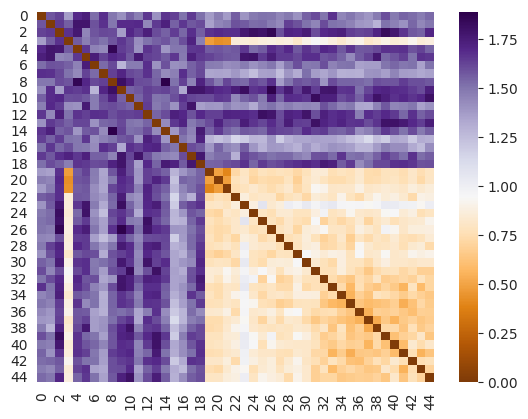

In [71]:
full_euc_norm = casmo_euc_dist_normalized + casmo_euc_dist_normalized.T

normal_euc_norm = (full_euc_norm - np.min(full_euc_norm)) / (np.max(full_euc_norm) - np.min(full_euc_norm))
sns.heatmap(normal_euc_norm + normal_hat, cmap="PuOr")

In all images it clearly shows that after the DoE Casmopolitan samples closer towards the incumbent found by the DoE (config ID 3, see wandb graph).

This is still not the full picture as there are depencies (auto variables) that Casmoplitan does not take into account, but the entire algorithm doesnt so yea....

# SMAC

Fun fact becuase of the way smac does opimization, it also just sampels random configs I think so all variables have a value, but not sure if this is just set to the default, or still a random sample from the possibilities

In [19]:
smac_table = pd.read_csv("storage_alice/state-run1/uniq_configurations-it20.csv", header=None)

In [26]:
# display(smac_table.head())
# print(smac_table.dtypes)

In [56]:
with open("storage_alice/state-run1/paramstrings-it20.txt") as filehandle:
    all_data = []
    for line in filehandle:
        line_dict = {}
        # print(f"{line}\n")
        rem_num = line.split(":")
        id = rem_num[0]
        all_vals = rem_num[1].split(",")
        # print(all_vals[1])
        line_dict["ID"] = id
        for arg_pair in all_vals:
            name, val = arg_pair.split("=")
            name = name.strip()
            val = val.rstrip()
            # print(val)
            # print(val[:-1])
            # print(name, float(val[1:-1]))
            # print(val)
            line_dict[name] = float(val[1:-1])
        all_data.append(line_dict)

smac_dataframe = pd.DataFrame(all_data)


In [57]:
display(smac_dataframe.head())

,ID,aggfill,aggregate,auto_aggfill_on,auto_barcorrectors,auto_barhomogeneous,auto_barorder,auto_bqpcuts_on,auto_branchdir_on,auto_cliquecuts_on,...,simplexpricing,startnodelimit,strongcgcuts,submipcuts,submipnodes,symmetry,threads,varbranch,zerohalfcuts,zeroobjnodes
0,1,1024.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,1000000.0,1.0,1.0,500.0,1.0,1.0,0.0,1.0,1000000.0
1,2,784.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,4559.0,0.0,1.0,574.0,1.0,1.0,1.0,1.0,327443.0
2,3,52.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,3.0,624659.0,1.0,2.0,1339.0,1.0,1.0,1.0,2.0,92754.0
3,4,1459.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,...,3.0,1439881.0,1.0,0.0,276.0,0.0,1.0,3.0,0.0,1432284.0
4,5,30.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,...,3.0,1500276.0,0.0,0.0,250.0,0.0,1.0,3.0,2.0,1148517.0


The reason this has 2 more is because of the ID and because of threads, that isnt in casmopolitain config

In [58]:
print(set(smac_dataframe.columns))

{'presolve', 'auto_degenmoves_on', 'impliedcuts', 'zeroobjnodes', 'auto_disconnected_on', 'covercuts', 'disconnected', 'auto_symmetry_on', 'auto_branchdir_on', 'projimpliedcuts', 'prepasses', 'auto_strongcgcuts_on', 'auto_aggfill_on', 'auto_zerohalfcuts_on', 'cliquecuts', 'auto_rltcuts_on', 'crossover', 'aggregate', 'auto_flowcovercuts_on', 'auto_minrelnodes_on', 'auto_sifting_on', 'auto_impliedcuts_on', 'auto_varbranch_on', 'barhomogeneous', 'auto_quad_on', 'auto_zeroobjnodes_on', 'mipsepcuts', 'cutaggpasses', 'partitionplace', 'auto_normadjust_on', 'flowpathcuts', 'degenmoves', 'bqpcuts', 'auto_mipsepcuts_on', 'rltcuts', 'nodemethod', 'auto_flowpathcuts_on', 'auto_presparsify_on', 'pumppasses', 'startnodelimit', 'auto_bqpcuts_on', 'auto_gubcovercuts_on', 'improvestarttime', 'normadjust', 'simplexpricing', 'auto_cutaggpasses_on', 'modkcuts', 'predual', 'auto_barcorrectors', 'auto_issmethod_on', 'mircuts', 'auto_crossover', 'auto_covercuts_on', 'shut_off_mip_start_processing', 'improve

### Hamming SMAC

38
(38, 38)


<Axes: >

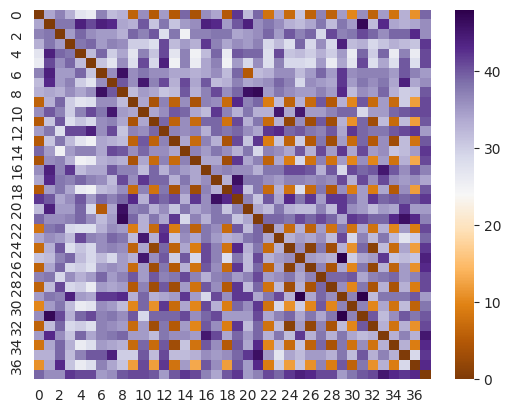

In [62]:
smac_hat_dist = build_hamming_dist_mat(casmo_configspace, smac_dataframe, cat_names, cont_names)
# print(casmo_hat_dist)
sns.heatmap(smac_hat_dist + smac_hat_dist.T, cmap="PuOr")

### Euc SMAC

38
(38, 38)


<Axes: >

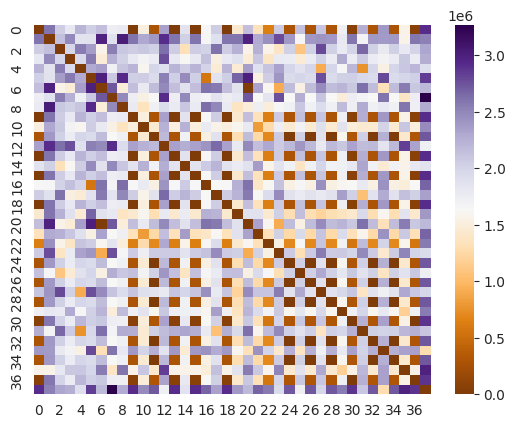

In [60]:
smac_euc_dist = build_euc_dist_mat(casmo_configspace, smac_dataframe, cat_names, cont_names)
sns.heatmap(smac_euc_dist + smac_euc_dist.T, cmap="PuOr")

### Normalized Euc SMAC

38
(38, 38)


<Axes: >

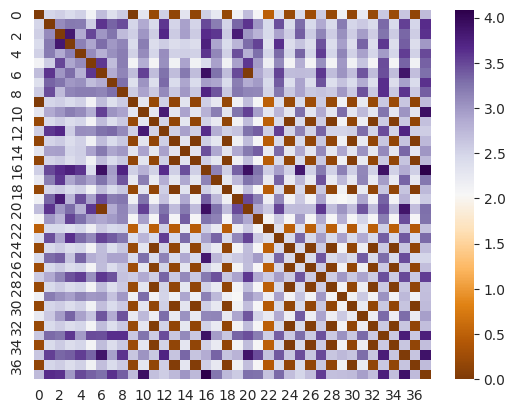

In [72]:
smac_euc_dist_normalized  = build_euc_dist_mat_normalized(casmo_configspace, smac_dataframe, cat_names, cont_names)
sns.heatmap(smac_euc_dist_normalized + smac_euc_dist_normalized.T, cmap="PuOr")

Interstingly enough, normalizing the distances for smac does not seem to have a major effect on the heatmap, while on the one for CASMO it did change quite a bit.

### Full unnormalized

<Axes: >

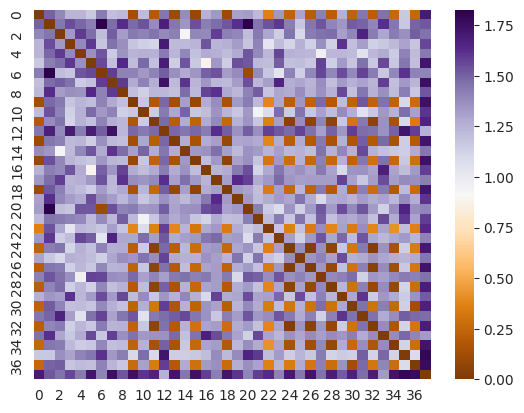

In [63]:
full_euc_smac = smac_euc_dist + smac_euc_dist.T
full_hat_smac = smac_hat_dist + smac_hat_dist.T

normal_euc_smac = (full_euc_smac - np.min(full_euc_smac)) / (np.max(full_euc_smac) - np.min(full_euc_smac))
normal_hat_smac = (full_hat_smac - np.min(full_hat_smac)) / (np.max(full_hat_smac) - np.min(full_hat_smac))
sns.heatmap(normal_euc_smac + normal_hat_smac, cmap="PuOr")

It basically looks like SMAC takes a config that is close to the enbumbent one time and on the next takes one far way/in another region, then one close to it again, then one further. So it looks like exploitation is only happening every second optimization step, wich I think they also mention intertwining with a random sample in their paper but I might be misremembering.

I should add a graph here with the actual runtimes of those configurations

It also kind of seems like smac does a kind of DOE implicitly? The first 10 configurations have higher distance and after that it starts to try and exploit it looks like? but maybe this is just a remnant of the RF model used?

### Full normalized

<Axes: >

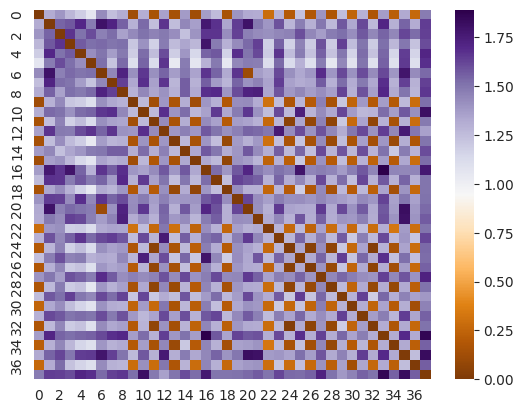

In [73]:
full_euc_smac_norm = smac_euc_dist_normalized + smac_euc_dist_normalized.T

normal_euc_smac_norm = (full_euc_smac_norm - np.min(full_euc_smac_norm)) / (np.max(full_euc_smac_norm) - np.min(full_euc_smac_norm))
sns.heatmap(normal_euc_smac_norm + normal_hat_smac, cmap="PuOr")